# EDA — CUFS Face Sketch Dataset
Notebook này thực hiện phân tích khám phá dữ liệu (EDA) cho bộ dữ liệu CUFS

Các hình sinh ra trong notebook này được dùng làm ảnh minh họa trong báo cáo:
- Hình 3.3 — Histogram độ sáng tập photo
- Hình 3.4 — Histogram pixel tập sketch
- Hình 3.5 — Scatter plot diện tích bbox
- Hình 3.6 — Lưới cặp ảnh đại diện

In [1]:
# ── Cài đặt thư viện (bỏ qua nếu đã có) ─────────────────────────────────────
# !pip install opencv-python-headless matplotlib pillow numpy tqdm -q

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image
from tqdm import tqdm

# ── Đường dẫn dataset — chỉnh lại cho phù hợp môi trường ───────────────────
PHOTO_DIR  = Path("../datasets/cufs/raw/photos")    # thư mục chứa ảnh chụp
SKETCH_DIR = Path("../datasets/cufs/raw/sketches")  # thư mục chứa sketch
SAVE_DIR   = Path("../figures/eda_figures")        # thư mục lưu hình cho báo cáo
SAVE_DIR.mkdir(exist_ok=True)

PHOTO_EXTS  = {".jpg", ".jpeg", ".png"}
SKETCH_EXTS = {".jpg", ".jpeg", ".png"}

# ── Nguồn gốc các file (dựa theo prefix tên file trong CUFS) ────────────────
SOURCE_MAP = {
    "f1": "CUHK Student",
    "F2": "CUHK Student",
    "f-": "CUHK Student",
    "m": "CUHK Student",
    "M2": "CUHK Student"
}

def get_source(stem: str) -> str:
    for prefix, name in SOURCE_MAP.items():
        if stem.startswith(prefix):
            return name
    return "Unknown"

print("Setup xong.")

Setup xong.


## 1. Load danh sách file và ghép cặp

In [3]:
# Build index sketch: stem → path
sketch_index = {}
for p in sorted(SKETCH_DIR.iterdir()):
    if p.suffix.lower() in SKETCH_EXTS and p.is_file():
        sketch_index[p.stem] = p

# Build index photo: stem+"-sz1" → path (để khớp tên sketch)
photo_index = {}
for p in sorted(PHOTO_DIR.iterdir()):
    if p.suffix.lower() in PHOTO_EXTS and p.is_file():
        photo_index[p.stem + "-sz1"] = p

# Ghép cặp
pairs = []
for sketch_stem, sketch_path in sketch_index.items():
    if sketch_stem in photo_index:
        pairs.append({
            "sketch": sketch_path,
            "photo":  photo_index[sketch_stem],
            "stem":   sketch_stem,
            "source": get_source(sketch_stem),
        })

print(f"Tổng số cặp ghép được : {len(pairs)}")
print(f"Sketch không match    : {len(sketch_index) - len(pairs)}")

# Phân chia theo nguồn
from collections import Counter
source_counts = Counter(p["source"] for p in pairs)
print("\nPhân chia theo nguồn:")
for src, cnt in source_counts.items():
    print(f"  {src:20s}: {cnt} cặp")

Tổng số cặp ghép được : 188
Sketch không match    : 0

Phân chia theo nguồn:
  CUHK Student        : 188 cặp


## 2. Thống kê cơ bản (Bảng 3.3)

In [4]:
photo_sizes   = []
sketch_sizes  = []
photo_means   = []
sketch_means  = []

for pair in tqdm(pairs, desc="Đọc ảnh"):
    ph = np.array(Image.open(pair["photo"]).convert("RGB"))
    sk = np.array(Image.open(pair["sketch"]).convert("RGB"))

    photo_sizes.append(ph.shape[:2])   # (H, W)
    sketch_sizes.append(sk.shape[:2])
    photo_means.append(ph.mean())
    sketch_means.append(sk.mean())

photo_sizes  = np.array(photo_sizes)
sketch_sizes = np.array(sketch_sizes)

print("=" * 50)
print(f"{'Thuộc tính':<30} {'Photo':>10} {'Sketch':>10}")
print("=" * 50)
print(f"{'Số lượng':<30} {len(pairs):>10} {len(pairs):>10}")
print(f"{'Chiều cao trung bình (H)':<30} {photo_sizes[:,0].mean():>10.1f} {sketch_sizes[:,0].mean():>10.1f}")
print(f"{'Chiều rộng trung bình (W)':<30} {photo_sizes[:,1].mean():>10.1f} {sketch_sizes[:,1].mean():>10.1f}")
print(f"{'Min H×W':<30} {photo_sizes[:,0].min()}×{photo_sizes[:,1].min():>4}  {sketch_sizes[:,0].min()}×{sketch_sizes[:,1].min():>4}")
print(f"{'Max H×W':<30} {photo_sizes[:,0].max()}×{photo_sizes[:,1].max():>4}  {sketch_sizes[:,0].max()}×{sketch_sizes[:,1].max():>4}")
print(f"{'Mean pixel value':<30} {np.mean(photo_means):>10.1f} {np.mean(sketch_means):>10.1f}")
print("=" * 50)

Đọc ảnh: 100%|██████████| 188/188 [00:00<00:00, 438.06it/s]

Thuộc tính                          Photo     Sketch
Số lượng                              188        188
Chiều cao trung bình (H)            250.0      250.0
Chiều rộng trung bình (W)           200.0      200.0
Min H×W                        250× 200  250× 200
Max H×W                        250× 200  250× 200
Mean pixel value                    153.4      205.7


## 3. Hình 3.3 — Histogram độ sáng tập Photo

Photo histogram: 100%|██████████| 188/188 [00:00<00:00, 1353.84it/s]


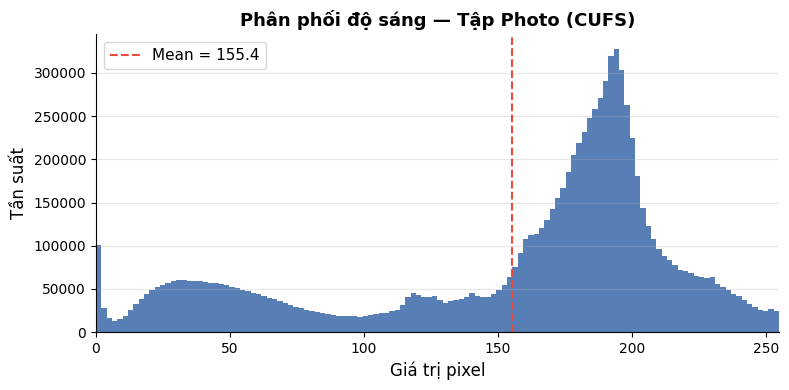

Saved: ..\figures\eda_figures\hinh_3_3_histogram_photo.png


In [5]:
# Tổng hợp histogram toàn bộ ảnh photo (kênh grayscale)
SAMPLE = pairs  # dùng toàn bộ

all_photo_pixels = []
for pair in tqdm(SAMPLE, desc="Photo histogram"):
    ph   = np.array(Image.open(pair["photo"]).convert("L"))  # grayscale
    all_photo_pixels.append(ph.flatten())

all_photo_pixels = np.concatenate(all_photo_pixels)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(all_photo_pixels, bins=128, color="#2E5FA3", alpha=0.8, edgecolor="none")
ax.axvline(all_photo_pixels.mean(), color="#E74C3C", linestyle="--", linewidth=1.5,
           label=f"Mean = {all_photo_pixels.mean():.1f}")
ax.set_xlabel("Giá trị pixel", fontsize=12)
ax.set_ylabel("Tần suất", fontsize=12)
ax.set_title("Phân phối độ sáng — Tập Photo (CUFS)", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.set_xlim(0, 255)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(SAVE_DIR / "hinh_3_3_histogram_photo.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {SAVE_DIR / 'hinh_3_3_histogram_photo.png'}")

## 4. Hình 3.4 — Histogram pixel tập Sketch

Sketch histogram: 100%|██████████| 188/188 [00:00<00:00, 1888.72it/s]


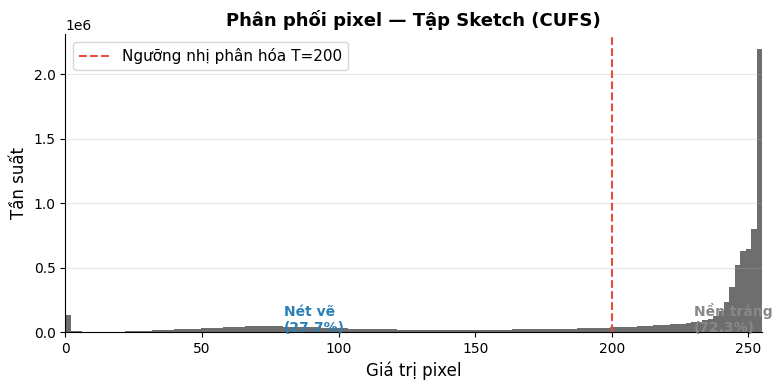

Tỷ lệ pixel nét vẽ (< 200): 27.72%
Tỷ lệ pixel nền trắng (>= 200): 72.28%


In [6]:
all_sketch_pixels = []
for pair in tqdm(SAMPLE, desc="Sketch histogram"):
    sk = np.array(Image.open(pair["sketch"]).convert("L"))
    all_sketch_pixels.append(sk.flatten())

all_sketch_pixels = np.concatenate(all_sketch_pixels)

# Tách thành 2 vùng: nét vẽ (<200) và nền (>=200)
nét  = all_sketch_pixels[all_sketch_pixels < 200]
nền  = all_sketch_pixels[all_sketch_pixels >= 200]
ratio_net = len(nét) / len(all_sketch_pixels) * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(all_sketch_pixels, bins=128, color="#555555", alpha=0.85, edgecolor="none")
ax.axvline(200, color="#E74C3C", linestyle="--", linewidth=1.5,
           label="Ngưỡng nhị phân hóa T=200")
ax.annotate(f"Nét vẽ\n({ratio_net:.1f}%)",
            xy=(80, ax.get_ylim()[1]*0.6 if ax.get_ylim()[1] > 0 else 1e6),
            fontsize=10, color="#2980B9", fontweight="bold",
            xytext=(80, 0), textcoords="data")
ax.annotate(f"Nền trắng\n({100-ratio_net:.1f}%)",
            xy=(230, 0), fontsize=10, color="#888", fontweight="bold",
            xytext=(230, 0), textcoords="data")
ax.set_xlabel("Giá trị pixel", fontsize=12)
ax.set_ylabel("Tần suất", fontsize=12)
ax.set_title("Phân phối pixel — Tập Sketch (CUFS)", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.set_xlim(0, 255)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(SAVE_DIR / "hinh_3_4_histogram_sketch.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Tỷ lệ pixel nét vẽ (< 200): {ratio_net:.2f}%")
print(f"Tỷ lệ pixel nền trắng (>= 200): {100-ratio_net:.2f}%")

## 5. Hình 3.5 — Scatter plot diện tích Bounding Box sketch

BBox analysis: 100%|██████████| 188/188 [00:00<00:00, 1739.00it/s]


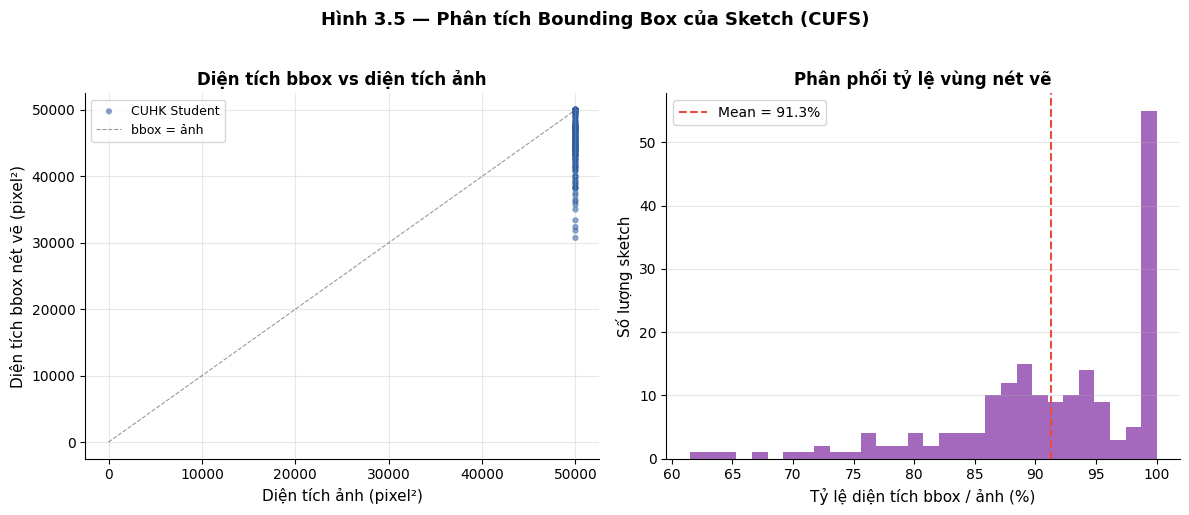


Tỷ lệ bbox/ảnh — Mean: 91.3%  Min: 61.5%  Max: 100.0%


In [7]:
total_areas = []
bbox_areas  = []
bbox_ratios = []
sources_list = []

for pair in tqdm(pairs, desc="BBox analysis"):
    sk   = np.array(Image.open(pair["sketch"]).convert("L"))
    H, W = sk.shape
    total_area = H * W

    _, binary = cv2.threshold(sk, 200, 255, cv2.THRESH_BINARY_INV)
    coords    = cv2.findNonZero(binary)
    if coords is None:
        continue

    x, y, w, h = cv2.boundingRect(coords)
    bbox_area  = w * h

    total_areas.append(total_area)
    bbox_areas.append(bbox_area)
    bbox_ratios.append(bbox_area / total_area * 100)
    sources_list.append(pair["source"])

total_areas  = np.array(total_areas)
bbox_areas   = np.array(bbox_areas)
bbox_ratios  = np.array(bbox_ratios)

# Màu theo nguồn
source_colors = {"CUHK Student": "#2E5FA3", "AR Face": "#E74C3C", "XM2VTS": "#27AE60", "Unknown": "#AAA"}
colors = [source_colors.get(s, "#AAA") for s in sources_list]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: diện tích ảnh vs diện tích bbox
ax = axes[0]
for src, color in source_colors.items():
    mask = [s == src for s in sources_list]
    if any(mask):
        ax.scatter(
            np.array(total_areas)[mask],
            np.array(bbox_areas)[mask],
            c=color, label=src, alpha=0.6, s=20, edgecolors="none"
        )
# Đường tham chiếu y=x (bbox = toàn ảnh)
lim = max(total_areas.max(), bbox_areas.max())
ax.plot([0, lim], [0, lim], "k--", linewidth=0.8, alpha=0.4, label="bbox = ảnh")
ax.set_xlabel("Diện tích ảnh (pixel²)", fontsize=11)
ax.set_ylabel("Diện tích bbox nét vẽ (pixel²)", fontsize=11)
ax.set_title("Diện tích bbox vs diện tích ảnh", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

# Histogram tỷ lệ bbox/ảnh
ax = axes[1]
ax.hist(bbox_ratios, bins=30, color="#8E44AD", alpha=0.8, edgecolor="none")
ax.axvline(bbox_ratios.mean(), color="#E74C3C", linestyle="--", linewidth=1.5,
           label=f"Mean = {bbox_ratios.mean():.1f}%")
ax.set_xlabel("Tỷ lệ diện tích bbox / ảnh (%)", fontsize=11)
ax.set_ylabel("Số lượng sketch", fontsize=11)
ax.set_title("Phân phối tỷ lệ vùng nét vẽ", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Hình 3.5 — Phân tích Bounding Box của Sketch (CUFS)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(SAVE_DIR / "hinh_3_5_bbox_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTỷ lệ bbox/ảnh — Mean: {bbox_ratios.mean():.1f}%  "
      f"Min: {bbox_ratios.min():.1f}%  Max: {bbox_ratios.max():.1f}%")

## 6. Hình 3.6 — Lưới cặp ảnh đại diện (3 nguồn × 4 cặp)

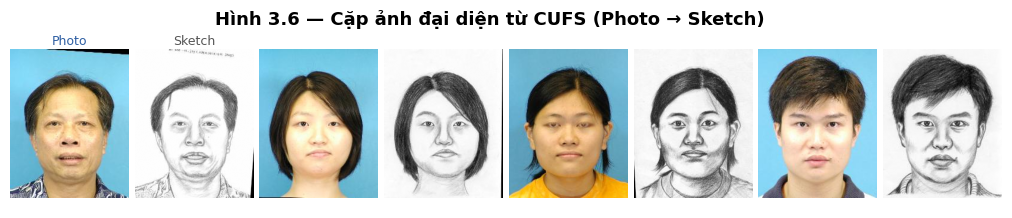

Saved: ..\figures\eda_figures\hinh_3_6_grid_pairs.png


In [8]:
import random
random.seed(42)

SOURCES_ORDER = ["CUHK Student"]
N_COLS = 4   # số cặp mỗi nguồn

# Lấy 4 cặp đại diện mỗi nguồn
selected = {}
for src in SOURCES_ORDER:
    pool = [p for p in pairs if p["source"] == src]
    selected[src] = random.sample(pool, min(N_COLS, len(pool)))

# Mỗi cặp chiếm 2 cột: photo | sketch
# Tổng: 3 hàng (nguồn) × 8 cột (4 cặp × 2)
N_ROWS  = len(SOURCES_ORDER)
N_SUBCOLS = N_COLS * 2

fig = plt.figure(figsize=(N_SUBCOLS * 1.6, N_ROWS * 2.2))
gs  = gridspec.GridSpec(N_ROWS, N_SUBCOLS, figure=fig,
                         hspace=0.05, wspace=0.05)

for row_idx, src in enumerate(SOURCES_ORDER):
    for col_idx, pair in enumerate(selected[src]):
        ph = np.array(Image.open(pair["photo"]).convert("RGB"))
        sk = np.array(Image.open(pair["sketch"]).convert("L"))

        # Photo
        ax_ph = fig.add_subplot(gs[row_idx, col_idx * 2])
        ax_ph.imshow(ph)
        ax_ph.axis("off")
        if row_idx == 0 and col_idx == 0:
            ax_ph.set_title("Photo", fontsize=9, color="#2E5FA3", pad=3)

        # Sketch
        ax_sk = fig.add_subplot(gs[row_idx, col_idx * 2 + 1])
        ax_sk.imshow(sk, cmap="gray")
        ax_sk.axis("off")
        if row_idx == 0 and col_idx == 0:
            ax_sk.set_title("Sketch", fontsize=9, color="#555", pad=3)

    # Label nguồn bên trái
    ax_label = fig.add_subplot(gs[row_idx, :])
    ax_label.axis("off")
    ax_label.set_ylabel(src, fontsize=10, fontweight="bold",
                        rotation=90, labelpad=5, color="#333")

fig.suptitle("Hình 3.6 — Cặp ảnh đại diện từ CUFS (Photo → Sketch)",
             fontsize=13, fontweight="bold", y=1.01)

plt.savefig(SAVE_DIR / "hinh_3_6_grid_pairs.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {SAVE_DIR / 'hinh_3_6_grid_pairs.png'}")

## 7. Tóm tắt thống kê EDA

In [9]:
print("\n" + "=" * 55)
print(" TỔNG KẾT EDA — CUFS Dataset")
print("=" * 55)
print(f" Tổng số cặp hợp lệ      : {len(pairs)}")
print()
for src, cnt in source_counts.items():
    print(f"  {src:<22}: {cnt} cặp ({cnt/len(pairs)*100:.1f}%)")
print()
print(f" Kích thước photo (HxW)  : {photo_sizes[:,0].mean():.0f} × {photo_sizes[:,1].mean():.0f}  (trung bình)")
print(f" Kích thước sketch (HxW) : {sketch_sizes[:,0].mean():.0f} × {sketch_sizes[:,1].mean():.0f}  (trung bình)")
print()
print(f" Mean pixel — photo      : {np.mean(photo_means):.1f} / 255")
print(f" Mean pixel — sketch     : {np.mean(sketch_means):.1f} / 255  (nền trắng)")
print()
print(f" Tỷ lệ nét vẽ / ảnh      : {bbox_ratios.mean():.1f}% ± {bbox_ratios.std():.1f}%")
print(f"   Min / Max             : {bbox_ratios.min():.1f}% / {bbox_ratios.max():.1f}%")
print("=" * 55)
print(f"\nHình đã lưu vào: {SAVE_DIR.resolve()}")


 TỔNG KẾT EDA — CUFS Dataset
 Tổng số cặp hợp lệ      : 188

  CUHK Student          : 188 cặp (100.0%)

 Kích thước photo (HxW)  : 250 × 200  (trung bình)
 Kích thước sketch (HxW) : 250 × 200  (trung bình)

 Mean pixel — photo      : 153.4 / 255
 Mean pixel — sketch     : 205.7 / 255  (nền trắng)

 Tỷ lệ nét vẽ / ảnh      : 91.3% ± 8.4%
   Min / Max             : 61.5% / 100.0%

Hình đã lưu vào: C:\Users\lqb464\Desktop\Sketch-to-Image-by-GAN\figures\eda_figures


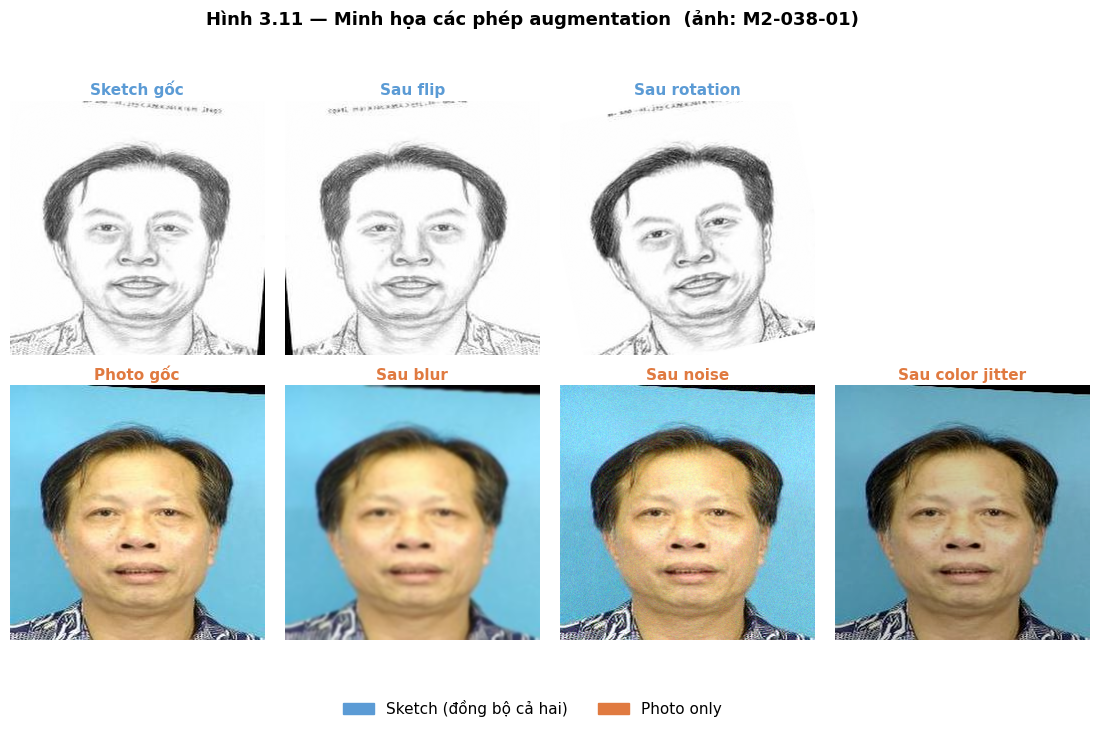

Saved → ..\figures\eda_figures\hinh_3_11_augmentation_demo.png


In [10]:
# ── Hình 3.11 — Minh họa các phép augmentation ───────────────────────
# Chạy sau khi đã có ảnh preprocessed (256×256)

import random
import cv2
import numpy as np
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

random.seed(42)
np.random.seed(42)

# ── Đường dẫn — chỉnh lại ──────────────────────────────────────────────────
PREPROCESSED_SKETCH = "../datasets/cufs/pipeline_output/preprocessed/sketch"
PREPROCESSED_PHOTO  = "../datasets/cufs/pipeline_output/preprocessed/photo"

# Lấy 1 cặp ngẫu nhiên làm demo
sketch_files = sorted(Path(PREPROCESSED_SKETCH).glob("*.jpg"))
photo_files  = sorted(Path(PREPROCESSED_PHOTO).glob("*.jpg"))
stem = random.choice(sketch_files).stem
sk_orig = np.array(Image.open(Path(PREPROCESSED_SKETCH) / f"{stem}.jpg").convert("RGB"))
photo_stem = stem.replace("-sz1", "")
ph_orig = np.array(Image.open(Path(PREPROCESSED_PHOTO)  / f"{photo_stem}.jpg").convert("RGB"))

# ── Các hàm transform (copy từ augmentation.py) ────────────────────────────

def do_flip(img):
    return np.fliplr(img).copy()

def do_rotation(img, angle, is_sketch=False):
    H, W = img.shape[:2]
    M = cv2.getRotationMatrix2D((W/2, H/2), angle, 1.0)
    border = cv2.BORDER_CONSTANT if is_sketch else cv2.BORDER_REFLECT_101
    val    = (255,255,255) if is_sketch else (0,0,0)
    return cv2.warpAffine(img, M, (W, H),
                          flags=cv2.INTER_LANCZOS4,
                          borderMode=border, borderValue=val)

def do_blur(img, sigma=1.2):
    return cv2.GaussianBlur(img, (0, 0), sigmaX=sigma)

def do_noise(img, std=8):
    noise = np.random.normal(0, std, img.shape).astype(np.float32)
    return np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

def do_jitter(img, strength=0.25):
    pil = Image.fromarray(img)
    for E in [ImageEnhance.Brightness, ImageEnhance.Contrast, ImageEnhance.Color]:
        pil = E(pil).enhance(1.0 + random.uniform(-strength, strength))
    return np.array(pil)

# ── Chuẩn bị ảnh cho từng ô ─────────────────────────────────────────────────
ANGLE = 12  # độ rotation demo

row_top = [
    ("Sketch gốc",       sk_orig,                          True),
    ("Sau flip",         do_flip(sk_orig),                 True),
    ("Sau rotation",     do_rotation(sk_orig, ANGLE, True),True),
]
row_bot = [
    ("Photo gốc",        ph_orig,                          False),
    ("Sau blur",         do_blur(ph_orig),                 False),
    ("Sau noise",        do_noise(ph_orig),                False),
    ("Sau color jitter", do_jitter(ph_orig),               False),
]

# ── Vẽ lưới 2 hàng × 4 cột (sketch chiếm 3 cột, photo chiếm 4 cột) ─────────
# Dùng gridspec để hàng trên 3 ô, hàng dưới 4 ô
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 7))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.12, wspace=0.06)

BORDER_SK = "#5B9BD5"   # xanh dương nhạt — sketch
BORDER_PH = "#E07A40"   # cam — photo

for col, (title, img, is_sk) in enumerate(row_top):
    ax = fig.add_subplot(gs[0, col])
    ax.imshow(img if not is_sk else img[:,:,0], cmap="gray" if is_sk else None)
    ax.set_title(title, fontsize=11, fontweight="bold",
                 color=BORDER_SK, pad=4)
    ax.axis("off")
    for spine in ax.spines.values():
        spine.set_edgecolor(BORDER_SK)
        spine.set_linewidth(2)
        spine.set_visible(True)

for col, (title, img, is_sk) in enumerate(row_bot):
    ax = fig.add_subplot(gs[1, col])
    ax.imshow(img)
    ax.set_title(title, fontsize=11, fontweight="bold",
                 color=BORDER_PH, pad=4)
    ax.axis("off")
    for spine in ax.spines.values():
        spine.set_edgecolor(BORDER_PH)
        spine.set_linewidth(2)
        spine.set_visible(True)

# Legend
patch_sk = mpatches.Patch(color=BORDER_SK, label="Sketch (đồng bộ cả hai)")
patch_ph = mpatches.Patch(color=BORDER_PH, label="Photo only")
fig.legend(handles=[patch_sk, patch_ph], loc="lower center",
           ncol=2, fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    f"Hình 3.11 — Minh họa các phép augmentation  (ảnh: {photo_stem})",
    fontsize=13, fontweight="bold", y=1.01
)

plt.savefig(SAVE_DIR / "hinh_3_11_augmentation_demo.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {SAVE_DIR / 'hinh_3_11_augmentation_demo.png'}")